<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%2010%20-%20Yolo/Yolo_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00


In [ ]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)


  data = {
      'path': '/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch',
      'train': 'train/images',
      'val': 'valid/images',
      'nc': number_of_classes,
      'names': classes
  }

  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

path_to_classes_txt = f'/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/classes.txt'
path_to_data_yaml = f'/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat "/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/data.yaml"

Created config file at /content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/data.yaml

File contents:

path: /content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch
train: train/images
val: valid/images
nc: 7
names:
- fish
- jellyfish
- penguins
- sharks
- puffins
- stingrays
- starfish


In [ ]:
!yolo detect train \
  data="/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/data.yaml" \
  model=yolo11s.pt \
  epochs=20 \
  imgsz=640

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, 

In [ ]:
!yolo detect predict model="/content/runs/detect/train-3/weights/best.pt" source="/content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/valid/images"

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs

image 1/127 /content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/valid/images/IMG_2277_jpeg_jpg.rf.86c72d6192da48d941ffa957f4780665.jpg: 640x480 16 fishs, 53.8ms
image 2/127 /content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/valid/images/IMG_2278_jpeg_jpg.rf.3c7006d683b0fc62b9b5d84a2868c31c.jpg: 640x480 9 fishs, 26.3ms
image 3/127 /content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/valid/images/IMG_2279_jpeg_jpg.rf.c93235205522529fc7e9626bf9175cba.jpg: 640x480 29 fishs, 12.3ms
image 4/127 /content/drive/MyDrive/Project and Learning Code/Aquarium Combined.v2-raw-1024.yolov7pytorch/valid/images/IMG_2288_jpeg_jpg.rf.18da58173e72084ebd73149bc8914ec1.jpg: 640x480 1 sharks, 12.2ms
image 5/127 /content/driv

In [ ]:
import glob
from IPython.display import Image, display

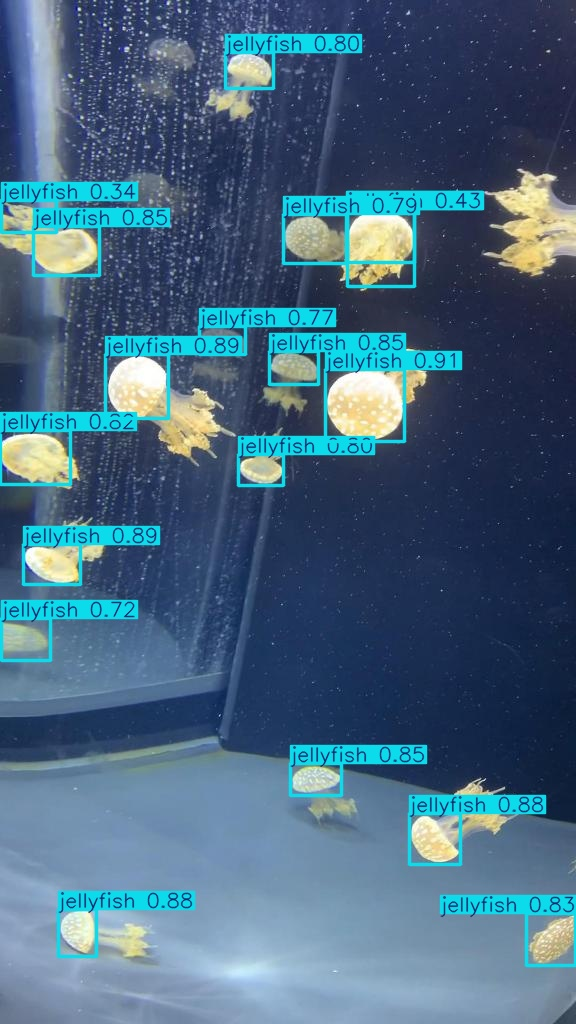

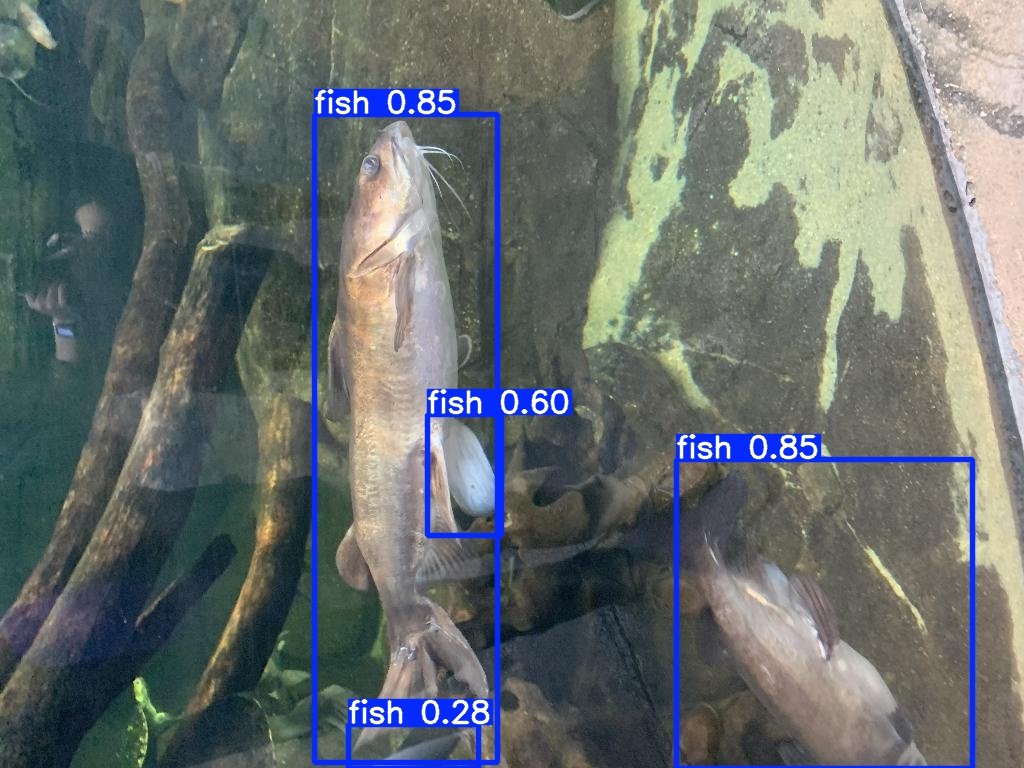

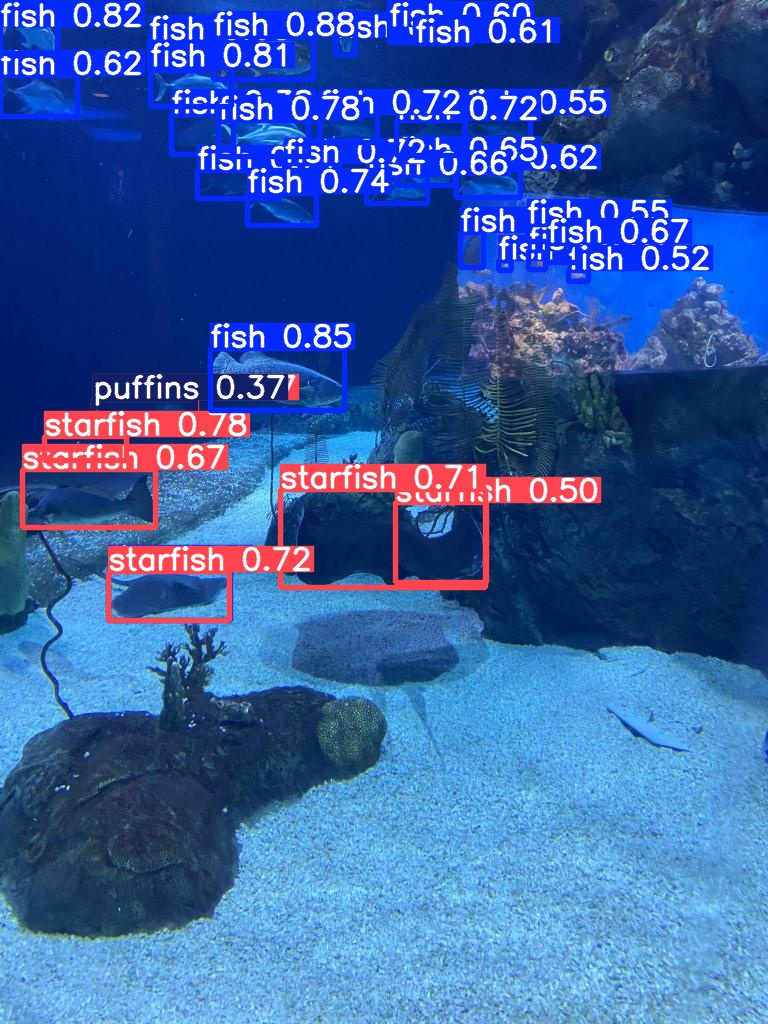

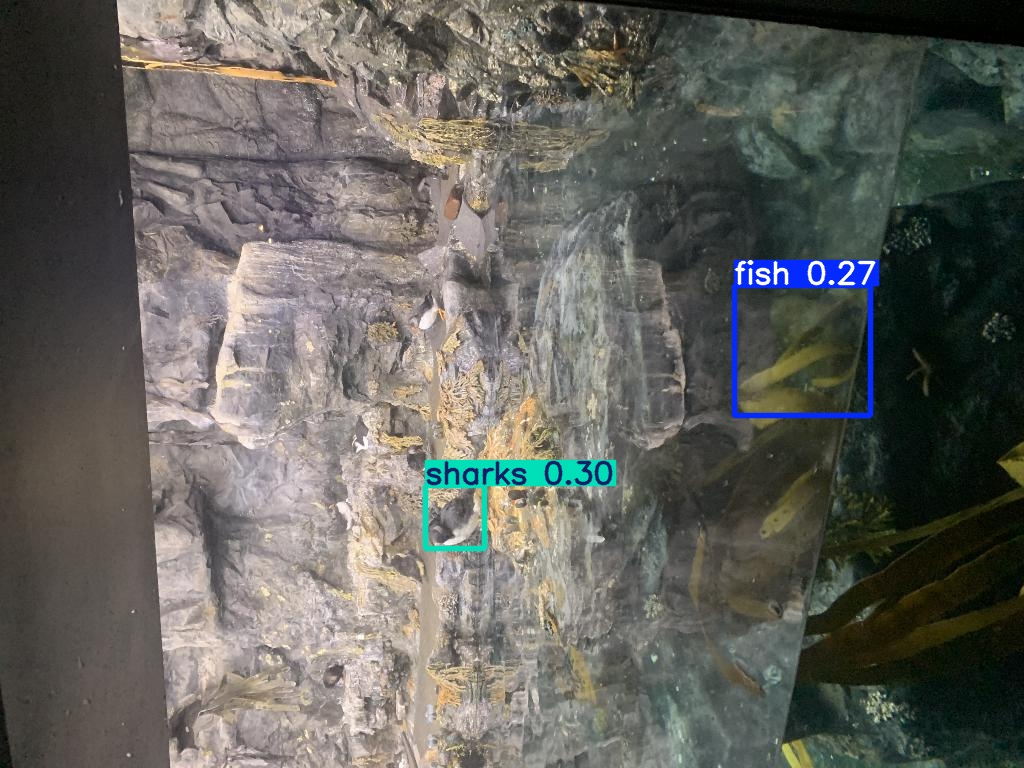

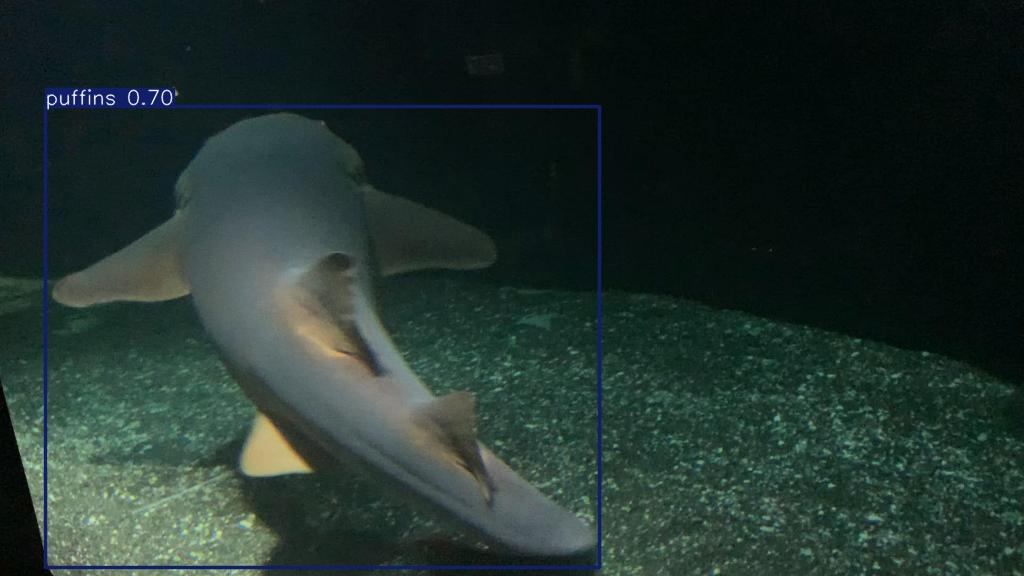

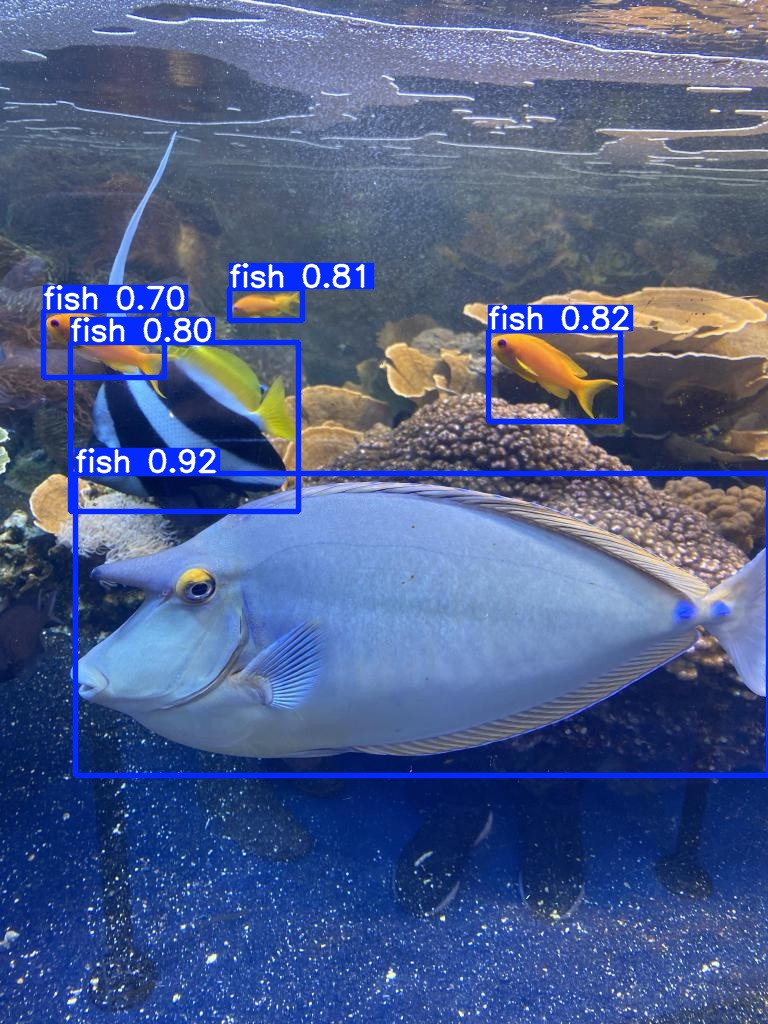

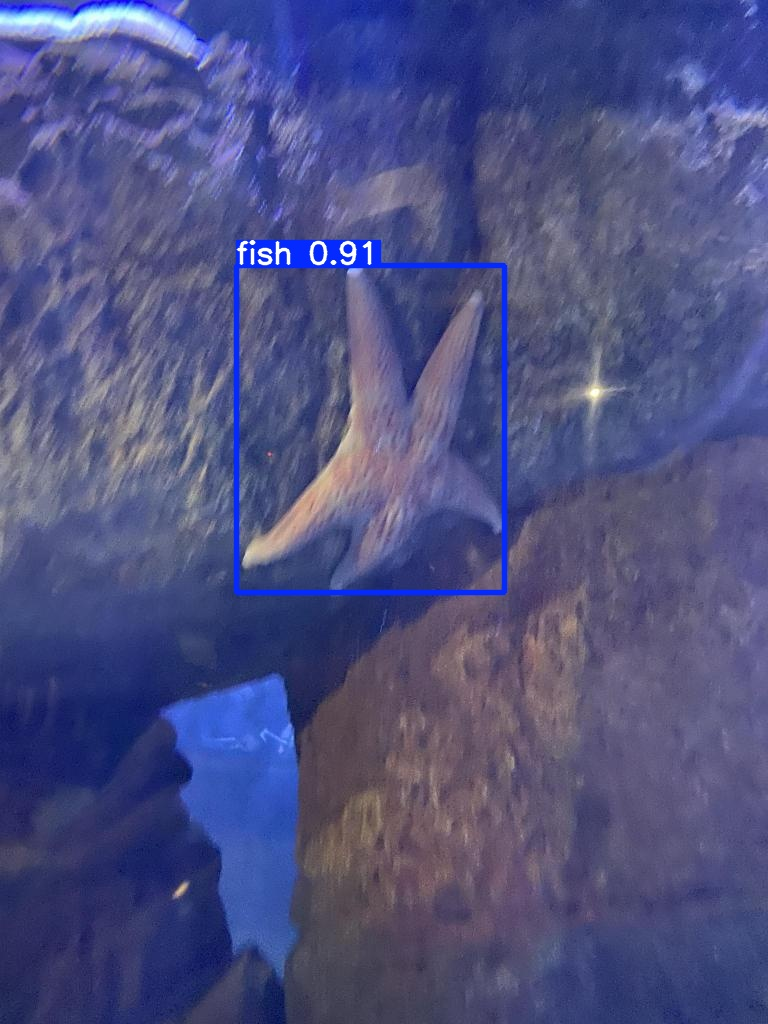

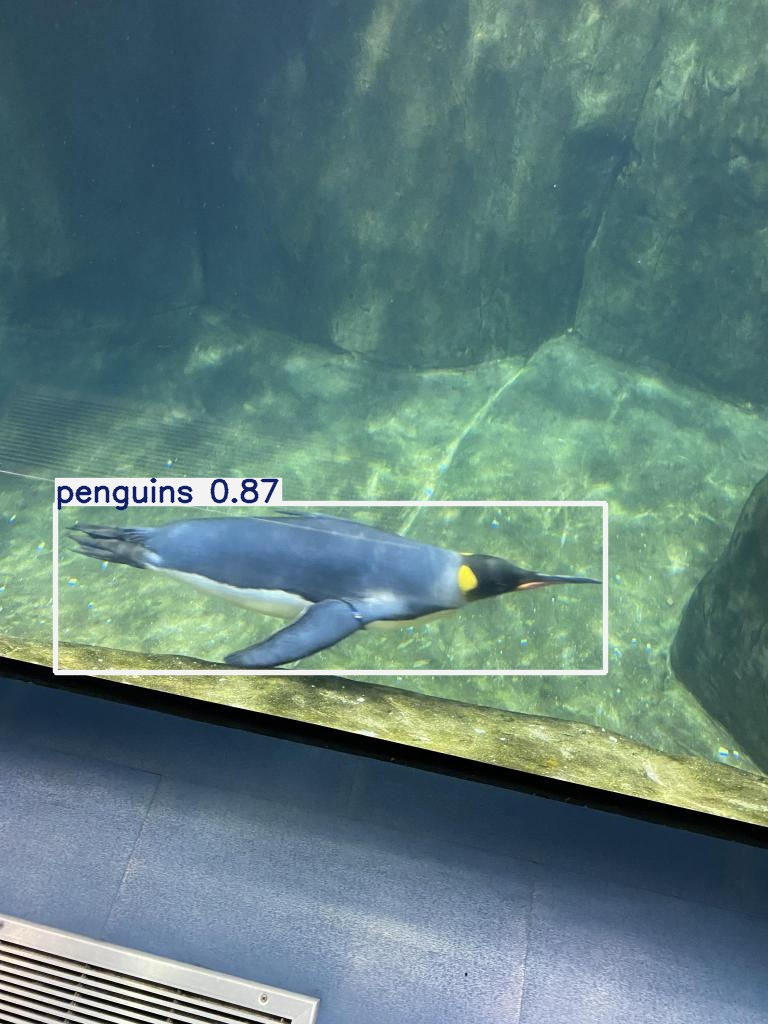

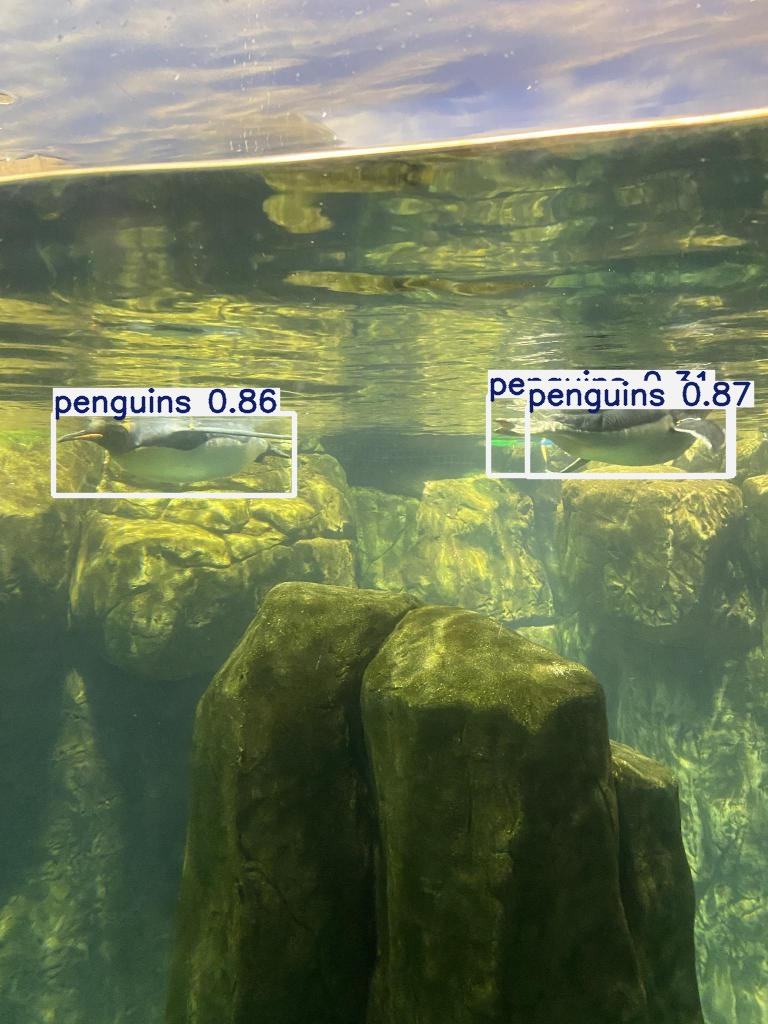

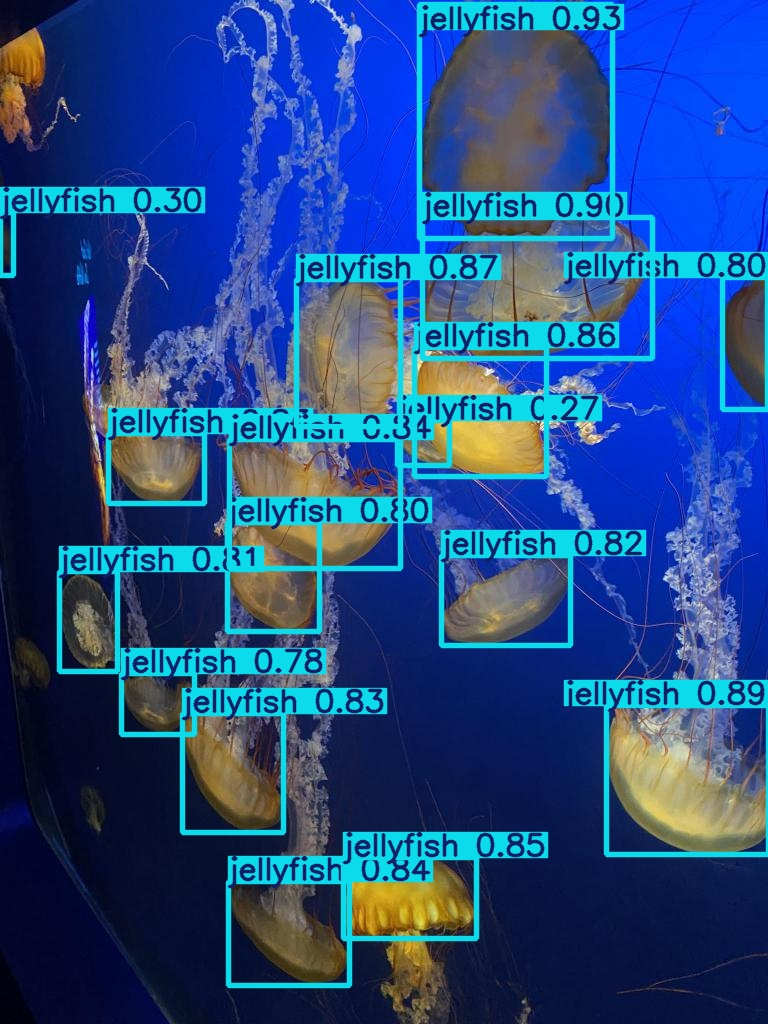

In [ ]:
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:30: 3]:
  display(Image(filename=image_path, height=400))
  print('\n')